<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/ammonia_refrigeration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ammonia as a refrigerant with NeqSim

This tutorial is for mechanical, process, and energy engineers who want to connect
refrigerant thermodynamics to a composable NeqSim process model.

**Prerequisites:** Python fundamentals, enthalpy, entropy, vapour–liquid equilibrium, and
steady-flow energy balances. All pressures are absolute. Calculations use SI units;
`bara` appears only where it is an explicit NeqSim pressure unit.

In [1]:
import importlib.metadata
import subprocess
import sys


try:
    neqsim_version = importlib.metadata.version("neqsim")
except importlib.metadata.PackageNotFoundError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )
    neqsim_version = importlib.metadata.version("neqsim")

print(f"NeqSim version: {neqsim_version}")

NeqSim version: 3.16.0


## Learning objectives

After completing the notebook, you should be able to:

1. calculate ammonia saturation pressures with a NeqSim equation of state;
2. construct the four states of a vapour-compression refrigeration cycle;
3. calculate refrigeration duty, compressor power, condenser duty, and COP;
4. represent the same cycle with NeqSim streams and unit operations;
5. verify valve isenthalpy, phase quality, mass balance, and energy balance; and
6. interpret evaporating-temperature, condensing-temperature, efficiency, and model
   sensitivities.

In [2]:
import platform
import subprocess

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.process import clearProcess, compressor, cooler, heater
from neqsim.process import runProcess, stream, valve


ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)

python_version = platform.python_version()
java_version = jpype.JClass("java.lang.System").getProperty("java.version")
java_runtime = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
).stderr.splitlines()[0]

plt.style.use("seaborn-v0_8-whitegrid")
print(f"Python version: {python_version}")
print(f"Java version: {java_version}")
print(f"Java runtime: {java_runtime}")

Python version: 3.12.13
Java version: 17.0.19
Java runtime: openjdk version "17.0.19" 2026-04-21


## NeqSim representation and calculation workflow

A NeqSim fluid stores composition, model, temperature, pressure, phases, and properties.
`ThermodynamicOperations` applies equilibrium or constrained flashes: TP for equilibrium,
PS for the ideal isentropic compressor reference, and PH for the valve outlet. A stream
carries a cloned fluid between units. The compressor, condenser cooler, valve, and
evaporator heater then solve the same state sequence as a connected process.

The model is Peng–Robinson (PR) with the classic mixing rule. PR is transparent, stable,
and suitable for a screening-level pure-ammonia cycle. The comparison with SRK later in
the notebook is a model-uncertainty check. Neither cubic model replaces a refrigerant
property standard or validated equipment design method.

In [3]:
MODEL_CLASSES = {
    "PR": jneqsim.thermo.system.SystemPrEos,
    "SRK": jneqsim.thermo.system.SystemSrkEos,
}


def make_ammonia(
    temperature_kelvin,
    pressure_bara,
    model_name="PR",
):
    model_class = MODEL_CLASSES[model_name]
    state = model_class(
        temperature_kelvin,
        pressure_bara,
    )
    state.addComponent("ammonia", 1.0)
    state.setMixingRule("classic")
    state.setMultiPhaseCheck(True)
    return state


def saturation_state(
    temperature_kelvin,
    boundary,
    model_name="PR",
):
    state = make_ammonia(
        temperature_kelvin,
        5.0,
        model_name,
    )
    operations = ThermodynamicOperations(state)
    if boundary == "dew":
        operations.dewPointPressureFlash()
    elif boundary == "bubble":
        operations.bubblePointPressureFlash()
    else:
        raise ValueError("boundary must be 'dew' or 'bubble'")
    state.initProperties()
    return state


def equilibrium_state(
    temperature_kelvin,
    pressure_bara,
    model_name="PR",
):
    state = make_ammonia(
        temperature_kelvin,
        pressure_bara,
        model_name,
    )
    ThermodynamicOperations(state).TPflash()
    state.initProperties()
    return state

## Pure-ammonia reference check

At the normal boiling point, liquid and vapour coexist at 1.01325 bara. The NIST Chemistry
WebBook reports 239.82 K for ammonia. This check tests the pure-fluid vapour-pressure scale
before it is used to set cycle pressures. It does not validate compressor performance or
heat-transfer design.

In [4]:
standard_pressure_bara = 1.01325
nist_normal_boiling_kelvin = 239.82

normal_boiling_state = make_ammonia(
    240.0,
    standard_pressure_bara,
)
normal_boiling_operations = ThermodynamicOperations(normal_boiling_state)
normal_boiling_operations.bubblePointTemperatureFlash()
normal_boiling_state.initProperties()

predicted_normal_boiling_kelvin = normal_boiling_state.getTemperature("K")
normal_boiling_difference_kelvin = (
    predicted_normal_boiling_kelvin - nist_normal_boiling_kelvin
)

print(f"Predicted normal boiling point [K]: {predicted_normal_boiling_kelvin:.5f}")
print(f"NIST normal boiling point [K]: {nist_normal_boiling_kelvin:.5f}")
print(f"Difference [K]: {normal_boiling_difference_kelvin:.5f}")

assert abs(normal_boiling_difference_kelvin) < 0.5

Predicted normal boiling point [K]: 239.61017
NIST normal boiling point [K]: 239.82000
Difference [K]: -0.20983


## Design basis, assumptions, and validity limits

The baseline is a single-stage cycle with 0.5 kg/s ammonia, −15 °C evaporation, 35 °C
condensation, 5 K suction superheat, 5 K liquid subcooling, and 75% compressor isentropic
efficiency. Pressure drops, oil, non-condensables, motor losses, heat leaks, and kinetic and
potential energy changes are neglected. The valve is adiabatic and isenthalpic.

Ammonia is toxic and mildly flammable. This educational calculation is not a safety,
materials, relief, ventilation, or machinery-selection study. Industrial work also needs
validated property data, compressor maps, approach temperatures, pressure losses, and
applicable codes.

In [5]:
mass_flow_kg_s = 0.5
evaporating_temperature_kelvin = 258.15
condensing_temperature_kelvin = 308.15
superheat_kelvin = 5.0
subcooling_kelvin = 5.0
compressor_efficiency = 0.75

evaporator_dew_state = saturation_state(
    evaporating_temperature_kelvin,
    "dew",
)
condenser_bubble_state = saturation_state(
    condensing_temperature_kelvin,
    "bubble",
)

low_pressure_bara = evaporator_dew_state.getPressure("bara")
high_pressure_bara = condenser_bubble_state.getPressure("bara")
pressure_ratio = high_pressure_bara / low_pressure_bara

design_basis_table = pd.DataFrame(
    {
        "Quantity": [
            "Mass flow",
            "Evaporating temperature",
            "Condensing temperature",
            "Low pressure",
            "High pressure",
            "Pressure ratio",
        ],
        "Value": [
            mass_flow_kg_s,
            evaporating_temperature_kelvin,
            condensing_temperature_kelvin,
            low_pressure_bara,
            high_pressure_bara,
            pressure_ratio,
        ],
        "Unit": ["kg/s", "K", "K", "bara", "bara", "-"],
    }
)
print(design_basis_table.round(5).to_string(index=False))

               Quantity     Value Unit
              Mass flow   0.50000 kg/s
Evaporating temperature 258.15000    K
 Condensing temperature 308.15000    K
           Low pressure   2.38340 bara
          High pressure  13.59029 bara
         Pressure ratio   5.70206    -


## Governing equations

For a steady adiabatic compressor, the isentropic reference has $s_{2s}=s_1$. The actual
specific work is calculated from the isentropic efficiency $\eta_{is}$:

$$

w_c = \frac{h_{2s}-h_1}{\eta_{is}}

$$

The valve satisfies $h_4=h_3$. The specific evaporator and condenser duties are

$$

q_{evap}=h_1-h_4

$$

$$

q_{cond}=h_2-h_3

$$

and the refrigeration coefficient of performance is $COP=q_{evap}/w_c$. Enthalpy is in
kJ/kg, specific work and heat are in kJ/kg, and multiplying by kg/s gives kW.

In [6]:
def run_ammonia_cycle(
    evaporating_temperature_kelvin,
    condensing_temperature_kelvin,
    compressor_efficiency=0.75,
    superheat_kelvin=5.0,
    subcooling_kelvin=5.0,
    model_name="PR",
):
    evaporator_dew = saturation_state(
        evaporating_temperature_kelvin,
        "dew",
        model_name,
    )
    condenser_bubble = saturation_state(
        condensing_temperature_kelvin,
        "bubble",
        model_name,
    )
    low_pressure = evaporator_dew.getPressure("bara")
    high_pressure = condenser_bubble.getPressure("bara")

    state_1 = equilibrium_state(
        evaporating_temperature_kelvin + superheat_kelvin,
        low_pressure,
        model_name,
    )

    state_2s = state_1.clone()
    state_2s.setPressure(high_pressure, "bara")
    inlet_entropy = state_1.getEntropy("kJ/kgK")
    ThermodynamicOperations(state_2s).PSflash(
        inlet_entropy,
        "kJ/kgK",
    )
    state_2s.initProperties()

    enthalpy_1 = state_1.getEnthalpy("kJ/kg")
    enthalpy_2s = state_2s.getEnthalpy("kJ/kg")
    enthalpy_2 = enthalpy_1 + (
        enthalpy_2s - enthalpy_1
    ) / compressor_efficiency
    state_2 = state_2s.clone()
    ThermodynamicOperations(state_2).PHflash(
        enthalpy_2,
        "kJ/kg",
    )
    state_2.initProperties()

    state_3 = equilibrium_state(
        condensing_temperature_kelvin - subcooling_kelvin,
        high_pressure,
        model_name,
    )
    enthalpy_3 = state_3.getEnthalpy("kJ/kg")

    state_4 = state_3.clone()
    state_4.setPressure(low_pressure, "bara")
    ThermodynamicOperations(state_4).PHflash(
        enthalpy_3,
        "kJ/kg",
    )
    state_4.initProperties()

    enthalpy_4 = state_4.getEnthalpy("kJ/kg")
    evaporator_duty = enthalpy_1 - enthalpy_4
    compressor_work = enthalpy_2 - enthalpy_1
    condenser_duty = enthalpy_2 - enthalpy_3
    coefficient_of_performance = evaporator_duty / compressor_work
    energy_residual = (
        condenser_duty - evaporator_duty - compressor_work
    )

    return {
        "states": [state_1, state_2, state_3, state_4],
        "low_pressure_bara": low_pressure,
        "high_pressure_bara": high_pressure,
        "evaporator_duty_kj_kg": evaporator_duty,
        "compressor_work_kj_kg": compressor_work,
        "condenser_duty_kj_kg": condenser_duty,
        "cop": coefficient_of_performance,
        "energy_residual_kj_kg": energy_residual,
    }


baseline_cycle = run_ammonia_cycle(
    evaporating_temperature_kelvin,
    condensing_temperature_kelvin,
    compressor_efficiency,
    superheat_kelvin,
    subcooling_kelvin,
)

## Four thermodynamic states

State 1 is superheated suction vapour, state 2 is compressor discharge, state 3 is
subcooled high-pressure liquid, and state 4 is the two-phase valve outlet. The phase
fraction is the gas-phase mole fraction reported by the flash. For a pure component it is
also the vapour mass quality because both phases contain only ammonia.

In [7]:
state_labels = [
    "1 evaporator outlet",
    "2 compressor outlet",
    "3 condenser outlet",
    "4 valve outlet",
]

state_table = pd.DataFrame(
    [
        {
            "State": label,
            "Temperature [K]": state.getTemperature("K"),
            "Pressure [bara]": state.getPressure("bara"),
            "Enthalpy [kJ/kg]": state.getEnthalpy("kJ/kg"),
            "Entropy [kJ/(kg K)]": state.getEntropy("kJ/kgK"),
            "Gas fraction [mol/mol]": state.getBeta(),
        }
        for label, state in zip(
            state_labels,
            baseline_cycle["states"],
        )
    ]
)
print(state_table.round(5).to_string(index=False))

              State  Temperature [K]  Pressure [bara]  Enthalpy [kJ/kg]  Entropy [kJ/(kg K)]  Gas fraction [mol/mol]
1 evaporator outlet         263.1500          2.38340         -34.48797             -0.53334                 1.00000
2 compressor outlet         395.1793         13.59029         304.95775             -0.31082                 1.00000
 3 condenser outlet         303.1500         13.59029       -1144.46761             -4.91262                 1.00000
     4 valve outlet         258.1500          2.38340       -1144.46761             -4.83262                 0.17711


## Performance and reversible limit

The actual cycle must reject the absorbed refrigeration heat plus compressor work. The
Carnot refrigerator operating between the saturation temperatures gives an upper bound:

$$

COP_{Carnot}=\frac{T_{evap}}{T_{cond}-T_{evap}}

$$

Absolute temperature in K is mandatory in this expression. The real COP should be
positive and below the Carnot value.

In [8]:
evaporator_capacity_kw = (
    mass_flow_kg_s * baseline_cycle["evaporator_duty_kj_kg"]
)
compressor_power_kw = (
    mass_flow_kg_s * baseline_cycle["compressor_work_kj_kg"]
)
condenser_duty_kw = (
    mass_flow_kg_s * baseline_cycle["condenser_duty_kj_kg"]
)
cycle_cop = baseline_cycle["cop"]
carnot_cop = evaporating_temperature_kelvin / (
    condensing_temperature_kelvin - evaporating_temperature_kelvin
)
energy_residual_kw = mass_flow_kg_s * baseline_cycle[
    "energy_residual_kj_kg"
]

performance_table = pd.Series(
    {
        "Refrigeration capacity [kW]": evaporator_capacity_kw,
        "Compressor power [kW]": compressor_power_kw,
        "Condenser heat rejection [kW]": condenser_duty_kw,
        "Cycle COP [-]": cycle_cop,
        "Carnot COP [-]": carnot_cop,
        "Energy residual [kW]": energy_residual_kw,
    }
)
print(performance_table.round(6).to_string())

assert evaporator_capacity_kw > 0.0
assert compressor_power_kw > 0.0
assert condenser_duty_kw > evaporator_capacity_kw
assert 0.0 < cycle_cop < carnot_cop
assert abs(energy_residual_kw) < 1.0e-9

Refrigeration capacity [kW]      554.989820
Compressor power [kW]            169.722859
Condenser heat rejection [kW]    724.712678
Cycle COP [-]                      3.269977
Carnot COP [-]                     5.163000
Energy residual [kW]              -0.000000


## The same cycle as a NeqSim process

Direct flashes expose the thermodynamic logic. A process model exposes named streams and
equipment that can be connected to larger simulations. The condenser is represented by a
`cooler`, the evaporator by a `heater`, and both are specified by outlet temperature. The
compressor sets outlet pressure and isentropic efficiency; the valve sets outlet pressure.

In [9]:
clearProcess()

process_fluid = baseline_cycle["states"][0].clone()
process_fluid.setTotalFlowRate(mass_flow_kg_s, "kg/sec")

suction_stream = stream(
    "Ammonia evaporator outlet",
    process_fluid,
)
ammonia_compressor = compressor(
    "Ammonia compressor",
    suction_stream,
    high_pressure_bara,
)
ammonia_compressor.setIsentropicEfficiency(compressor_efficiency)

ammonia_condenser = cooler(
    "Ammonia condenser",
    ammonia_compressor.getOutletStream(),
)
ammonia_condenser.setOutTemperature(
    condensing_temperature_kelvin - subcooling_kelvin,
    "K",
)

expansion_valve = valve(
    "Ammonia expansion valve",
    ammonia_condenser.getOutletStream(),
    low_pressure_bara,
)

ammonia_evaporator = heater(
    "Ammonia evaporator",
    expansion_valve.getOutletStream(),
)
ammonia_evaporator.setOutTemperature(
    evaporating_temperature_kelvin + superheat_kelvin,
    "K",
)

runProcess()

## Process results and unit conventions

NeqSim's compressor reports power in kW. Heater and cooler `getDuty()` values are in W, so
this notebook divides them by 1000 before comparison. Cooling duty is negative because
heat leaves the refrigerant; evaporator duty is positive because heat enters it.

In [10]:
process_streams = [
    suction_stream,
    ammonia_compressor.getOutletStream(),
    ammonia_condenser.getOutletStream(),
    expansion_valve.getOutletStream(),
    ammonia_evaporator.getOutletStream(),
]
process_state_labels = [
    "Suction",
    "Discharge",
    "Condenser outlet",
    "Valve outlet",
    "Evaporator outlet",
]

process_state_table = pd.DataFrame(
    [
        {
            "State": label,
            "Temperature [K]": process_stream.getTemperature("K"),
            "Pressure [bara]": process_stream.getPressure("bara"),
            "Mass flow [kg/s]": process_stream.getFlowRate("kg/sec"),
            "Gas fraction [mol/mol]": process_stream.getFluid().getBeta(),
        }
        for label, process_stream in zip(
            process_state_labels,
            process_streams,
        )
    ]
)
print(process_state_table.round(6).to_string(index=False))

process_compressor_power_kw = ammonia_compressor.getPower("kW")
process_condenser_duty_kw = ammonia_condenser.getDuty() / 1000.0
process_evaporator_duty_kw = ammonia_evaporator.getDuty() / 1000.0

process_duty_table = pd.Series(
    {
        "Compressor power [kW]": process_compressor_power_kw,
        "Condenser duty [kW]": process_condenser_duty_kw,
        "Evaporator duty [kW]": process_evaporator_duty_kw,
    }
)
print(process_duty_table.round(6).to_string())

            State  Temperature [K]  Pressure [bara]  Mass flow [kg/s]  Gas fraction [mol/mol]
          Suction       263.150000         2.383399               0.5                1.000000
        Discharge       395.179302        13.590286               0.5                1.000000
 Condenser outlet       303.150000        13.590286               0.5                1.000000
     Valve outlet       258.150000         2.383399               0.5                0.177113
Evaporator outlet       263.150000         2.383399               0.5                1.000000
Compressor power [kW]    169.722859
Condenser duty [kW]     -724.712678
Evaporator duty [kW]     554.989820


## Independent process checks

The process must preserve mass flow through every unit. The valve must preserve specific
enthalpy, and its outlet must contain both liquid and vapour. The algebraic energy residual
uses heat into the refrigerant as positive:

$$

R_E=Q_{evap}+W_c+Q_{cond}

$$

A residual near zero confirms that the independently reported unit duties close.

In [11]:
process_mass_flows_kg_s = np.array(
    [
        process_stream.getFlowRate("kg/sec")
        for process_stream in process_streams
    ]
)
maximum_mass_residual_kg_s = np.max(
    np.abs(process_mass_flows_kg_s - mass_flow_kg_s)
)

valve_inlet_enthalpy_kj_kg = (
    expansion_valve.getInletStream().getFluid().getEnthalpy("kJ/kg")
)
valve_outlet_enthalpy_kj_kg = (
    expansion_valve.getOutletStream().getFluid().getEnthalpy("kJ/kg")
)
valve_enthalpy_residual_kj_kg = (
    valve_outlet_enthalpy_kj_kg - valve_inlet_enthalpy_kj_kg
)
process_energy_residual_kw = (
    process_evaporator_duty_kw
    + process_compressor_power_kw
    + process_condenser_duty_kw
)
valve_gas_fraction = expansion_valve.getOutletStream().getFluid().getBeta()

print(f"Maximum mass residual [kg/s]: {maximum_mass_residual_kg_s:.3e}")
print(f"Valve enthalpy residual [kJ/kg]: {valve_enthalpy_residual_kj_kg:.3e}")
print(f"Process energy residual [kW]: {process_energy_residual_kw:.3e}")
print(f"Valve outlet gas fraction [mol/mol]: {valve_gas_fraction:.6f}")

assert maximum_mass_residual_kg_s < 1.0e-10
assert abs(valve_enthalpy_residual_kj_kg) < 1.0e-6
assert abs(process_energy_residual_kw) < 1.0e-6
assert 0.0 < valve_gas_fraction < 1.0

Maximum mass residual [kg/s]: 0.000e+00
Valve enthalpy residual [kJ/kg]: 0.000e+00
Process energy residual [kW]: 0.000e+00
Valve outlet gas fraction [mol/mol]: 0.177113


## Valve-outlet quality by an enthalpy lever rule

For pure ammonia at the evaporating pressure, an independent quality estimate follows
from saturated-liquid enthalpy $h_f$, saturated-vapour enthalpy $h_g$, and valve-outlet
enthalpy $h_4$:

$$

x_4=\frac{h_4-h_f}{h_g-h_f}

$$

Agreement with the flash phase fraction verifies both phase identification and the
isenthalpic expansion result.

In [12]:
saturated_liquid_low = saturation_state(
    evaporating_temperature_kelvin,
    "bubble",
)
saturated_vapour_low = saturation_state(
    evaporating_temperature_kelvin,
    "dew",
)

saturated_liquid_enthalpy_kj_kg = saturated_liquid_low.getEnthalpy("kJ/kg")
saturated_vapour_enthalpy_kj_kg = saturated_vapour_low.getEnthalpy("kJ/kg")
valve_outlet_enthalpy_kj_kg = baseline_cycle["states"][3].getEnthalpy(
    "kJ/kg"
)
lever_rule_quality = (
    valve_outlet_enthalpy_kj_kg - saturated_liquid_enthalpy_kj_kg
) / (
    saturated_vapour_enthalpy_kj_kg - saturated_liquid_enthalpy_kj_kg
)
flash_quality = baseline_cycle["states"][3].getBeta()
quality_residual = flash_quality - lever_rule_quality

print(f"Flash quality [kg/kg]: {flash_quality:.8f}")
print(f"Lever-rule quality [kg/kg]: {lever_rule_quality:.8f}")
print(f"Quality residual [kg/kg]: {quality_residual:.3e}")

assert 0.0 < lever_rule_quality < 1.0
assert abs(quality_residual) < 1.0e-7

Flash quality [kg/kg]: 0.17711285
Lever-rule quality [kg/kg]: 0.17711285
Quality residual [kg/kg]: 6.430e-11


## Evaporating-temperature sensitivity

Raising the evaporating temperature increases suction pressure and reduces compressor
lift when the condensing temperature is fixed. The expected screening trend is a lower
pressure ratio and a higher COP. Each point reruns all saturation and flash calculations,
so the plot is not a fitted curve.

 Evaporating temperature [°C]  Low pressure [bara]  Pressure ratio [-]  COP [-]
                        -25.0              1.52998             8.88263  2.51834
                        -20.0              1.91912             7.08152  2.85943
                        -15.0              2.38340             5.70206  3.26998
                        -10.0              2.93260             4.63421  3.77316
                         -5.0              3.57711             3.79923  5.13821


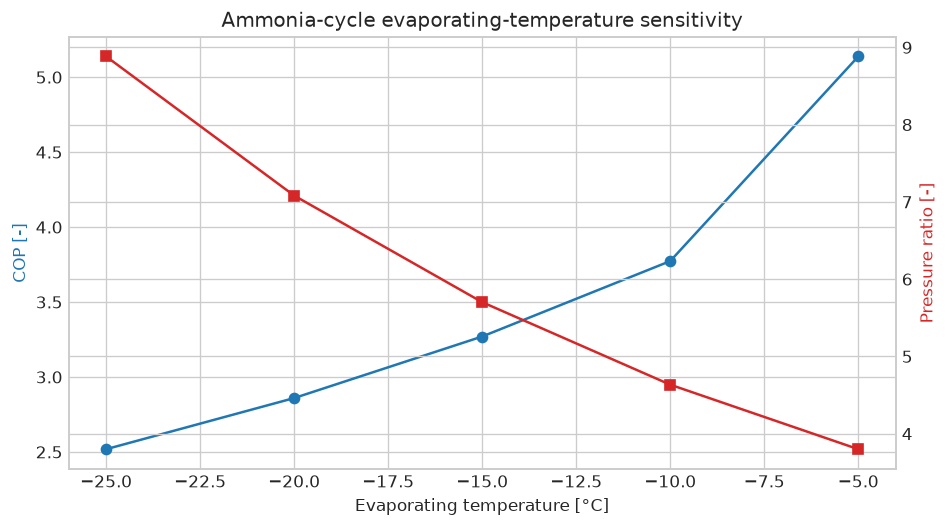

In [13]:
evaporating_temperatures_c = np.array(
    [-25.0, -20.0, -15.0, -10.0, -5.0]
)
evaporating_scenarios = []

for evaporating_temperature_c in evaporating_temperatures_c:
    scenario = run_ammonia_cycle(
        evaporating_temperature_c + 273.15,
        condensing_temperature_kelvin,
        compressor_efficiency,
        superheat_kelvin,
        subcooling_kelvin,
    )
    scenario_pressure_ratio = (
        scenario["high_pressure_bara"]
        / scenario["low_pressure_bara"]
    )
    evaporating_scenarios.append(
        {
            "Evaporating temperature [°C]": evaporating_temperature_c,
            "Low pressure [bara]": scenario["low_pressure_bara"],
            "Pressure ratio [-]": scenario_pressure_ratio,
            "COP [-]": scenario["cop"],
        }
    )

evaporating_sensitivity = pd.DataFrame(evaporating_scenarios)
print(evaporating_sensitivity.round(5).to_string(index=False))

figure, first_axis = plt.subplots(figsize=(8.0, 4.5))
second_axis = first_axis.twinx()
first_axis.plot(
    evaporating_sensitivity["Evaporating temperature [°C]"],
    evaporating_sensitivity["COP [-]"],
    marker="o",
    color="tab:blue",
    label="COP",
)
second_axis.plot(
    evaporating_sensitivity["Evaporating temperature [°C]"],
    evaporating_sensitivity["Pressure ratio [-]"],
    marker="s",
    color="tab:red",
    label="Pressure ratio",
)
first_axis.set_xlabel("Evaporating temperature [°C]")
first_axis.set_ylabel("COP [-]", color="tab:blue")
second_axis.set_ylabel("Pressure ratio [-]", color="tab:red")
first_axis.set_title("Ammonia-cycle evaporating-temperature sensitivity")
figure.tight_layout()
plt.show()

assert np.all(np.diff(evaporating_sensitivity["COP [-]"]) > 0.0)
assert np.all(
    np.diff(evaporating_sensitivity["Pressure ratio [-]"]) < 0.0
)

## Condensing temperature and compressor efficiency

A warmer heat sink increases condensing pressure and compressor lift, so COP should fall.
Higher isentropic efficiency reduces the required work for the same pressure lift, so COP
should rise. These scenarios isolate one input at a time; they do not represent a matched
compressor map or part-load control system.

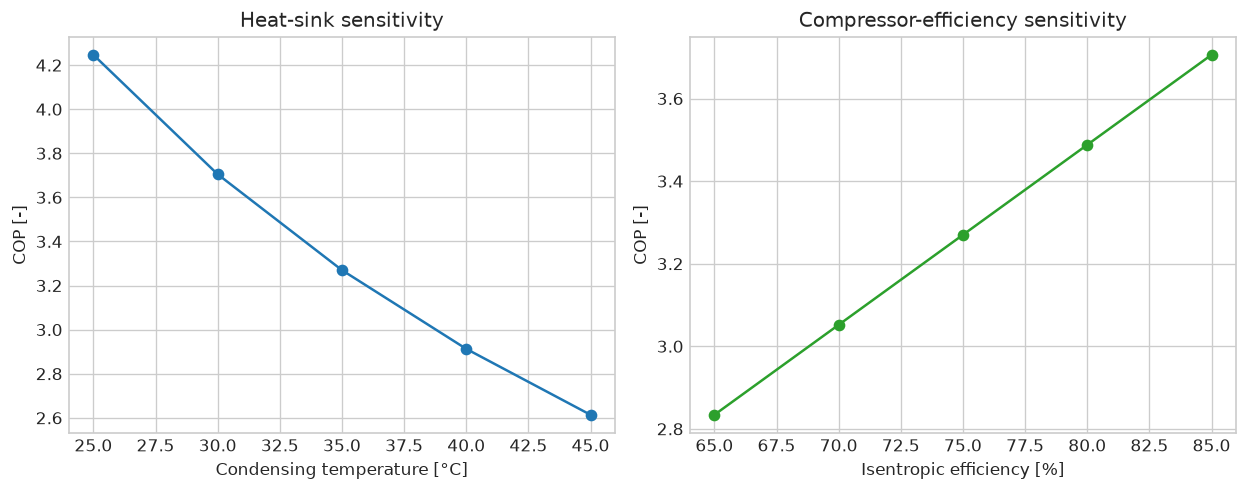

In [14]:
condensing_temperatures_c = np.array(
    [25.0, 30.0, 35.0, 40.0, 45.0]
)
efficiency_values = np.array(
    [0.65, 0.70, 0.75, 0.80, 0.85]
)

condensing_cops = []
discharge_temperatures_c = []
for condensing_temperature_c in condensing_temperatures_c:
    scenario = run_ammonia_cycle(
        evaporating_temperature_kelvin,
        condensing_temperature_c + 273.15,
        compressor_efficiency,
        superheat_kelvin,
        subcooling_kelvin,
    )
    condensing_cops.append(scenario["cop"])
    discharge_temperatures_c.append(
        scenario["states"][1].getTemperature("C")
    )

efficiency_cops = []
for efficiency_value in efficiency_values:
    scenario = run_ammonia_cycle(
        evaporating_temperature_kelvin,
        condensing_temperature_kelvin,
        efficiency_value,
        superheat_kelvin,
        subcooling_kelvin,
    )
    efficiency_cops.append(scenario["cop"])

figure, axes = plt.subplots(
    1,
    2,
    figsize=(10.5, 4.2),
)
axes[0].plot(
    condensing_temperatures_c,
    condensing_cops,
    marker="o",
    label="COP",
)
axes[0].set_xlabel("Condensing temperature [°C]")
axes[0].set_ylabel("COP [-]")
axes[0].set_title("Heat-sink sensitivity")
axes[1].plot(
    100.0 * efficiency_values,
    efficiency_cops,
    marker="o",
    color="tab:green",
)
axes[1].set_xlabel("Isentropic efficiency [%]")
axes[1].set_ylabel("COP [-]")
axes[1].set_title("Compressor-efficiency sensitivity")
figure.tight_layout()
plt.show()

assert np.all(np.diff(condensing_cops) < 0.0)
assert np.all(np.diff(discharge_temperatures_c) > 0.0)
assert np.all(np.diff(efficiency_cops) > 0.0)

## Thermodynamic-model sensitivity

PR and SRK share a cubic-EOS framework but use different attractive-term parameters. The
spread between them is not a confidence interval. It is a useful warning that property
model choice changes pressures, work, and COP even for pure ammonia. Design work should
compare against a validated ammonia formulation over the exact operating range.

In [15]:
model_rows = []
for model_name in MODEL_CLASSES:
    model_cycle = run_ammonia_cycle(
        evaporating_temperature_kelvin,
        condensing_temperature_kelvin,
        compressor_efficiency,
        superheat_kelvin,
        subcooling_kelvin,
        model_name,
    )
    model_rows.append(
        {
            "Model": model_name,
            "Low pressure [bara]": model_cycle["low_pressure_bara"],
            "High pressure [bara]": model_cycle["high_pressure_bara"],
            "Compressor work [kJ/kg]": model_cycle[
                "compressor_work_kj_kg"
            ],
            "COP [-]": model_cycle["cop"],
        }
    )

model_sensitivity = pd.DataFrame(model_rows)
model_cop_spread_percent = 100.0 * (
    model_sensitivity["COP [-]"].max()
    - model_sensitivity["COP [-]"].min()
) / model_sensitivity["COP [-]"].mean()

print(model_sensitivity.round(6).to_string(index=False))
print(f"Relative PR/SRK COP spread [%]: {model_cop_spread_percent:.4f}")

assert np.isfinite(model_sensitivity.select_dtypes(float).to_numpy()).all()
assert model_cop_spread_percent < 10.0

Model  Low pressure [bara]  High pressure [bara]  Compressor work [kJ/kg]  COP [-]
   PR             2.383399             13.590286               339.445718 3.269977
  SRK             2.358798             13.731502               345.218741 3.249710
Relative PR/SRK COP spread [%]: 0.6217


## Pressure–enthalpy view

A pressure–enthalpy diagram makes the cycle topology visible: compression moves to higher
pressure and enthalpy, condensation rejects heat at high pressure, throttling preserves
enthalpy, and evaporation absorbs heat at low pressure. Straight lines connect calculated
end states; they are not detailed equipment paths.

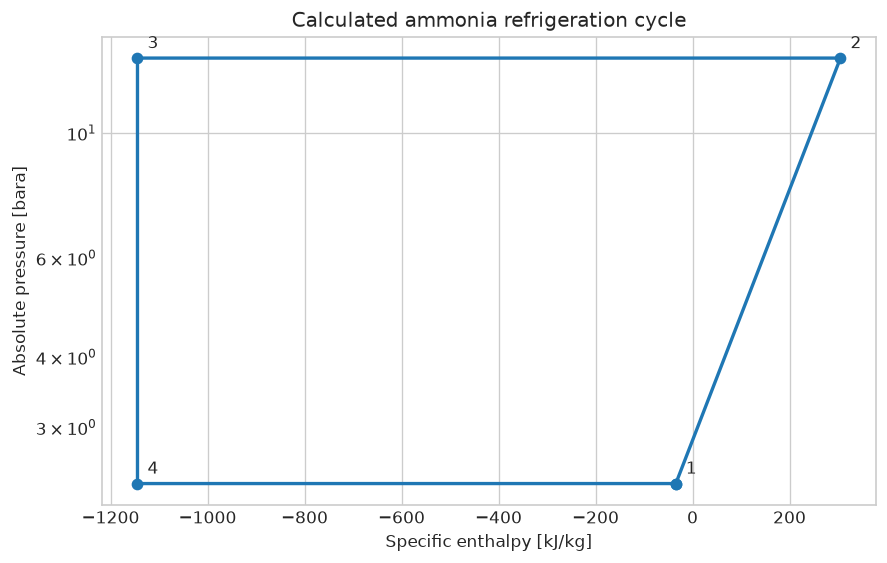

In [16]:
cycle_states_closed = baseline_cycle["states"] + [
    baseline_cycle["states"][0]
]
cycle_enthalpies_kj_kg = [
    state.getEnthalpy("kJ/kg")
    for state in cycle_states_closed
]
cycle_pressures_bara = [
    state.getPressure("bara")
    for state in cycle_states_closed
]

figure, axis = plt.subplots(figsize=(7.5, 4.8))
axis.plot(
    cycle_enthalpies_kj_kg,
    cycle_pressures_bara,
    marker="o",
    linewidth=2.0,
)
for state_number, state in enumerate(
    baseline_cycle["states"],
    start=1,
):
    axis.annotate(
        str(state_number),
        (
            state.getEnthalpy("kJ/kg"),
            state.getPressure("bara"),
        ),
        xytext=(6, 6),
        textcoords="offset points",
    )
axis.set_yscale("log")
axis.set_xlabel("Specific enthalpy [kJ/kg]")
axis.set_ylabel("Absolute pressure [bara]")
axis.set_title("Calculated ammonia refrigeration cycle")
figure.tight_layout()
plt.show()

## Consolidated verification

The final gate combines independent evidence: the NIST normal-boiling benchmark,
thermodynamic and process energy balances, valve isenthalpy, quality agreement, phase and
pressure ordering, process/direct-method agreement, and sensitivity trends. Passing these
checks supports a reproducible teaching example, not design certification.

In [17]:
direct_process_power_residual_kw = (
    process_compressor_power_kw - compressor_power_kw
)
direct_process_evaporator_residual_kw = (
    process_evaporator_duty_kw - evaporator_capacity_kw
)
direct_process_condenser_residual_kw = (
    -process_condenser_duty_kw - condenser_duty_kw
)

validation_checks = {
    "normal boiling benchmark": abs(normal_boiling_difference_kelvin) < 0.5,
    "positive refrigeration duty": evaporator_capacity_kw > 0.0,
    "positive compressor power": compressor_power_kw > 0.0,
    "COP below Carnot": 0.0 < cycle_cop < carnot_cop,
    "direct cycle energy closure": abs(energy_residual_kw) < 1.0e-9,
    "process energy closure": abs(process_energy_residual_kw) < 1.0e-6,
    "process mass closure": maximum_mass_residual_kg_s < 1.0e-10,
    "valve isenthalpy": abs(valve_enthalpy_residual_kj_kg) < 1.0e-6,
    "two-phase valve outlet": 0.0 < valve_gas_fraction < 1.0,
    "quality agreement": abs(quality_residual) < 1.0e-7,
    "pressure ordering": high_pressure_bara > low_pressure_bara,
    "temperature ordering": (
        baseline_cycle["states"][1].getTemperature("K")
        > baseline_cycle["states"][0].getTemperature("K")
    ),
    "direct/process compressor agreement": (
        abs(direct_process_power_residual_kw) < 1.0e-4
    ),
    "direct/process evaporator agreement": (
        abs(direct_process_evaporator_residual_kw) < 1.0e-4
    ),
    "direct/process condenser agreement": (
        abs(direct_process_condenser_residual_kw) < 1.0e-4
    ),
    "warmer evaporation raises COP": (
        np.all(np.diff(evaporating_sensitivity["COP [-]"]) > 0.0)
    ),
    "warmer condensation lowers COP": np.all(np.diff(condensing_cops) < 0.0),
    "higher efficiency raises COP": np.all(np.diff(efficiency_cops) > 0.0),
    "finite model comparison": np.isfinite(
        model_sensitivity.select_dtypes(float).to_numpy()
    ).all(),
}

failed_checks = [
    check_name
    for check_name, passed in validation_checks.items()
    if not passed
]
assert not failed_checks, failed_checks

print(f"Engineering checks passed: {len(validation_checks)}")
print(f"Cycle COP [-]: {cycle_cop:.5f}")
print(f"Refrigeration capacity [kW]: {evaporator_capacity_kw:.5f}")
print(f"Compressor power [kW]: {compressor_power_kw:.5f}")
print(f"Process energy residual [kW]: {process_energy_residual_kw:.3e}")

Engineering checks passed: 19
Cycle COP [-]: 3.26998
Refrigeration capacity [kW]: 554.98982
Compressor power [kW]: 169.72286
Process energy residual [kW]: 0.000e+00


## Troubleshooting, summary, and further work

**Troubleshooting.** Use absolute pressure in `bara`, use K in the Carnot equation, and
initialize saturation flashes near the expected pressure. If a heat exchanger remains in
the wrong phase at exact saturation, specify a physically meaningful superheat or
subcooling margin. Rebuild each sensitivity state instead of reusing a mutated fluid.

**Summary.** The baseline PR cycle calculates saturation pressures, a two-phase
isenthalpic expansion, positive refrigeration duty, and a COP below the reversible limit.
Direct flashes and the connected process model agree while independently closing mass and
energy balances.

**Exercises.** Add suction-line pressure drop; compare 0, 5, and 10 K superheat; calculate
compressor displacement from suction density; add motor efficiency; or replace the fixed
condensing temperature with an approach to ambient air.

**Authoritative references**

- [NIST Chemistry WebBook: ammonia phase-change data](https://webbook.nist.gov/cgi/cbook.cgi?ID=C7664417&Mask=4)
- [NeqSim thermodynamic model selection](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [NeqSim thermodynamic operations](https://equinor.github.io/neqsim/thermodynamicoperations/README.html)
- [NeqSim process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html)